In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cftime

In [2]:
netcdf_path = '/Users/yugao/UOP/ORS-processing/data/processed/stratus/'
# Load the dataset
# Replace 'your_data.nc' with the path to your dataset file
ds = xr.open_dataset(netcdf_path + '/stratus12_sbe16_1876.nc')

/Users/yugao/miniforge3/envs/ors/lib/python3.12/site-packages/xarray/coding/times.py:995: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/yugao/miniforge3/envs/ors/lib/python3.12/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()


In [3]:
# Access the 'time_coverage_start' attribute
time_coverage_start_str = ds.attrs['time_coverage_start']

# Assuming the time_coverage_start is in a standard ISO format or similar,
# and you need to work with cftime objects
import cftime

# Parse the start date string into a cftime object
# The exact function to use depends on your calendar; assuming Gregorian here
time_coverage_start = cftime.num2date(0, units=f"days since {time_coverage_start_str}", calendar='gregorian')
# Define an end date, for instance, one year after the start
end_date = cftime.DatetimeGregorian(time_coverage_start.year + 1, time_coverage_start.month, time_coverage_start.day)

In [4]:
time_coverage_start_str = ds.attrs['time_coverage_start']

In [5]:
# Assuming temp is a NumPy array or a pandas Series containing temperature values
# Calculate the difference in temperature between consecutive time steps
temp = ds.temp.data
# Now temp_diff contains the temperature differences

In [6]:
def convert_cftime_to_pandas_timestamp(ds, start_date='2012-05-14T00:59:59Z'):
    """
    Convert cftime.DatetimeGregorian objects to pandas.Timestamp objects,
    using the provided start date as the reference start date.
    
    Parameters:
    ds (xarray.Dataset): Dataset with a 'time' variable containing cftime.DatetimeGregorian objects.
    start_date (str): Start date in ISO format (e.g., '2012-05-14T00:59:59Z').
    
    Returns:
    numpy.ndarray: Array of pandas.Timestamp objects representing the dataset's time points.
    """
    # Convert the start date string to a pandas.Timestamp
    reference_date = pd.to_datetime(start_date)
    
    # Calculate the time offsets in hours from the reference start date
    # Use the first time point in the dataset as the base for offsets
    first_time_point = ds.time.values[0]
    base_offset_hours = cftime.date2num([first_time_point], units="hours since 2000-01-01", calendar='gregorian')[0]
    
    # Calculate offsets for all time points in the dataset relative to the first time point
    time_offsets_hours = cftime.date2num(ds.time.values, units="hours since 2000-01-01", calendar='gregorian') - base_offset_hours
    
    # Apply the offsets to the reference date to get pandas.Timestamp objects
    regular_time_array = np.array([reference_date + pd.Timedelta(hours=offset) for offset in time_offsets_hours])
    
    return regular_time_array


In [7]:
regular_time_array = convert_cftime_to_pandas_timestamp(ds)
# Now 'regular_time_array' contains the converted time data as pandas.Timestamp objects
len(regular_time_array)

31872

In [46]:
import pandas as pd
import numpy as np

def filter_valid_hourly_data(ds):
    """
    Filter valid hourly oceanographic data based on multiple criteria.

    Parameters:
    ds (xarray.Dataset): The input dataset containing temperature and salinity data.

    Returns:
    xarray.Dataset: The filtered dataset.
    """
    # Define criteria thresholds
    temp_range = (0, 30)  # Acceptable temperature range
    sal_range = (30, 40)   # Acceptable salinity range
    min_observation_duration = pd.Timedelta(days=365)  # Minimum observation duration

    # Temporal Consistency: Rolling window standard deviation
    temp_std = ds['temp'].rolling(time=24).std()
    sal_std = ds['sal'].rolling(time=24).std()

    # Range Constraints
    valid_temp_range = (ds['temp'] >= temp_range[0]) & (ds['temp'] <= temp_range[1])
    valid_sal_range = (ds['sal'] >= sal_range[0]) & (ds['sal'] <= sal_range[1])

    # Temporal Duration
    observation_duration = ds['time'][-1] - ds['time'][0]
    valid_duration = observation_duration >= min_observation_duration

    # Combine criteria
    valid_criteria = valid_temp_range & valid_sal_range & (temp_std < 5) & (sal_std < 2) & valid_duration

    # Filter data based on criteria
    filtered_ds = ds.where(valid_criteria, drop=True)

    return filtered_ds


In [47]:
filtered_ds = filter_valid_hourly_data(ds)

In [48]:
filtered_ds

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 31158)
Coordinates:
  * time     (time) object 249kB 3912-05-30 09:29:59.999993 ... 3914-03-10 12...
Data variables:
    temp     (time) float64 249kB 1.821 1.821 1.82 1.82 ... 1.768 3.788 17.68
    cond     (time) float64 249kB 3.218 3.218 3.218 3.218 ... 3.191 3.247 4.583
    sal      (time) float64 249kB 34.69 34.69 34.69 34.69 ... 34.43 33.05 33.76
    sal_sbe  (time) float64 249kB 34.69 34.69 34.69 34.69 ... 34.43 33.05 33.76
Attributes: (12/25)
    depth:                                  4502
    latitude:                               -19.93844
    longitude:                              -85.29266333333334
    instrument_model:                       SBE-16
    instrument_SN:                          1876
    instrument_manufacturer:                SeaBird Electronics
    ...                                     ...
    water_depth_from_mooring_diagram:       4450
    water_depth_from_ship_uncorrected:      4562.2
    water_depth_from_ship_corrected:        4538.97
    instrument_depth_from_mooring_diagram:  4411
    instrument_depth_from_mooring_log:      4499.97
    instrument_height_above_bottom:         39

In [49]:
# regular_time_array = convert_cftime_to_pandas_timestamp(filtered_ds)
# len(regular_time_array)

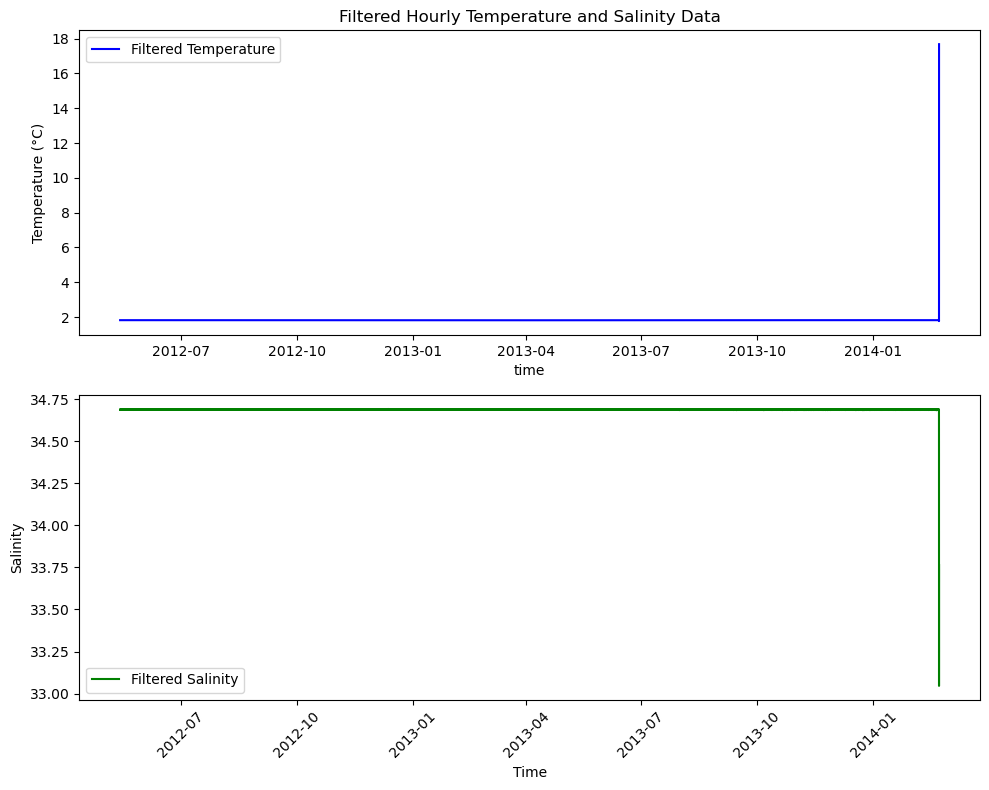

In [50]:
import matplotlib.pyplot as plt

# Step 1: Convert cftime to pandas.Timestamp
regular_time_array = convert_cftime_to_pandas_timestamp(filtered_ds, start_date='2012-05-14T00:59:59Z')

# Step 2: Filter the dataset based on criteria
filtered_ds = filter_valid_hourly_data(ds)

# Step 3: Set the time coordinate of the filtered dataset to the regular time array
filtered_ds = filtered_ds.assign_coords(time=regular_time_array)

# Step 4: Create subplots for temperature and salinity
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot filtered temperature data
filtered_ds.temp[:].plot(ax=ax1, label='Filtered Temperature', color='blue')
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Filtered Hourly Temperature and Salinity Data')

# Plot filtered salinity data
filtered_ds.sal[:].plot(ax=ax2, label='Filtered Salinity', color='green')
ax2.set_ylabel('Salinity')
ax2.set_xlabel('Time')

# Customize x-axis ticks and labels for both subplots
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# Add legend to both subplots
ax1.legend()
ax2.legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


In [53]:
filtered_ds.temp[-10:]

<xarray.DataArray 'temp' (time: 10)> Size: 80B
array([ 1.8209,  1.8209,  1.8209,  1.82  ,  1.8209,  1.8209,  1.8209,
        1.7675,  3.7883, 17.6838])
Coordinates:
  * time     (time) object 80B 2014-02-21T22:59:59.000006704+00:00 ... 2014-0...
Attributes:
    units:    units_placeholder